In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('/content/archive (3).zip')
df.head(6)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26


In [ ]:
df.shape

(16598, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rank,16598.0,8300.605254,4791.853933,1.00,4151.25,8300.50,12449.75,16600.00
Year,16327.0,2006.406443,5.828981,1980.00,2003.00,2007.00,2010.00,2020.00
NA_Sales,16598.0,0.264667,0.816683,0.00,0.00,0.08,0.24,41.49
EU_Sales,16598.0,0.146652,0.505351,0.00,0.00,0.02,0.11,29.02
JP_Sales,16598.0,0.077782,0.309291,0.00,0.00,0.00,0.04,10.22
Other_Sales,16598.0,0.048063,0.188588,0.00,0.00,0.01,0.04,10.57
Global_Sales,16598.0,0.537441,1.555028,0.01,0.06,0.17,0.47,82.74


In [ ]:
#Checking missing values.....
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [ ]:
#Handling missing values......
df['Year']=df['Year'].fillna(df['Year'].median())
df['Publisher']=df['Publisher'].fillna(df['Publisher'].mode()[0])

In [ ]:
#Checking duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#Outlier analysis
num_cols = ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

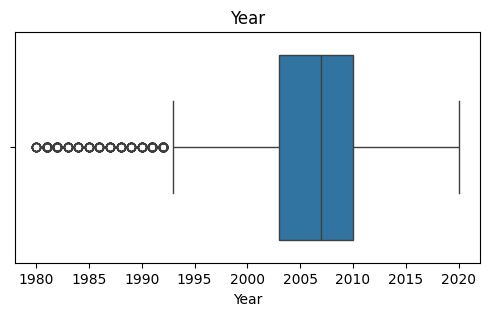

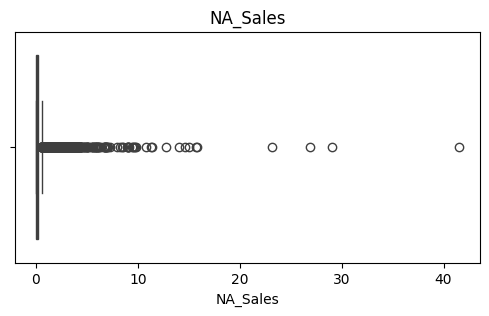

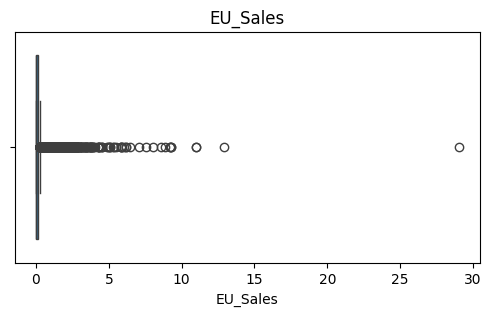

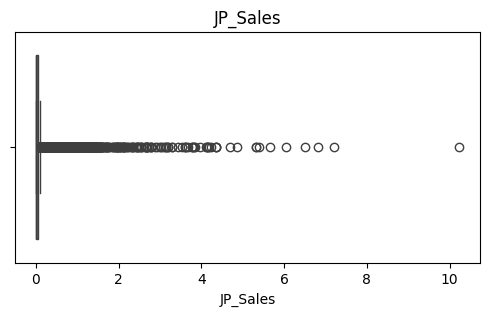

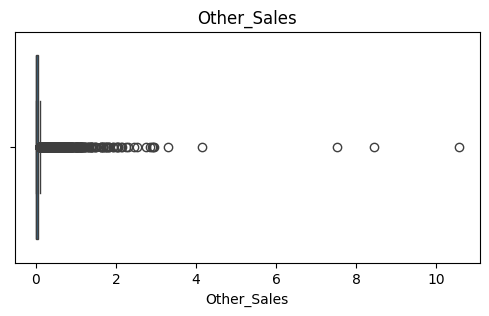

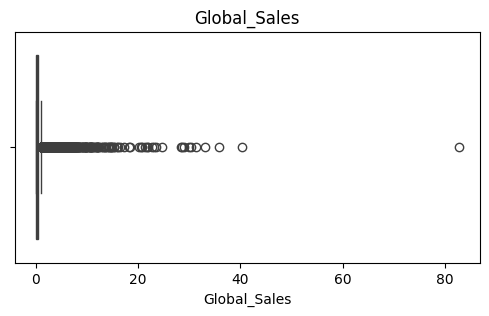

In [ ]:
#Boxplots
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
#Skewness
df[num_cols].skew()

,0
Year,-1.015600
NA_Sales,18.799627
EU_Sales,18.875535
JP_Sales,11.206458
Other_Sales,24.233923
Global_Sales,17.400645


In [ ]:
#IQR method
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(col, len(outliers))

Year 305
NA_Sales 1681
EU_Sales 2081
JP_Sales 2425
Other_Sales 1665
Global_Sales 1893


In [ ]:
#Log transformation
df['Global_Sales'] = np.log1p(df['Global_Sales'])
df['NA_Sales'] = np.log1p(df['NA_Sales'])
df['EU_Sales'] = np.log1p(df['EU_Sales'])
df['JP_Sales'] = np.log1p(df['JP_Sales'])
df['Other_Sales'] = np.log1p(df['Other_Sales'])

In [ ]:
#Checking skewness again.....
df[num_cols].skew()

,0
Year,-1.015600
NA_Sales,3.412044
EU_Sales,4.303477
JP_Sales,5.453000
Other_Sales,7.267784
Global_Sales,2.749624


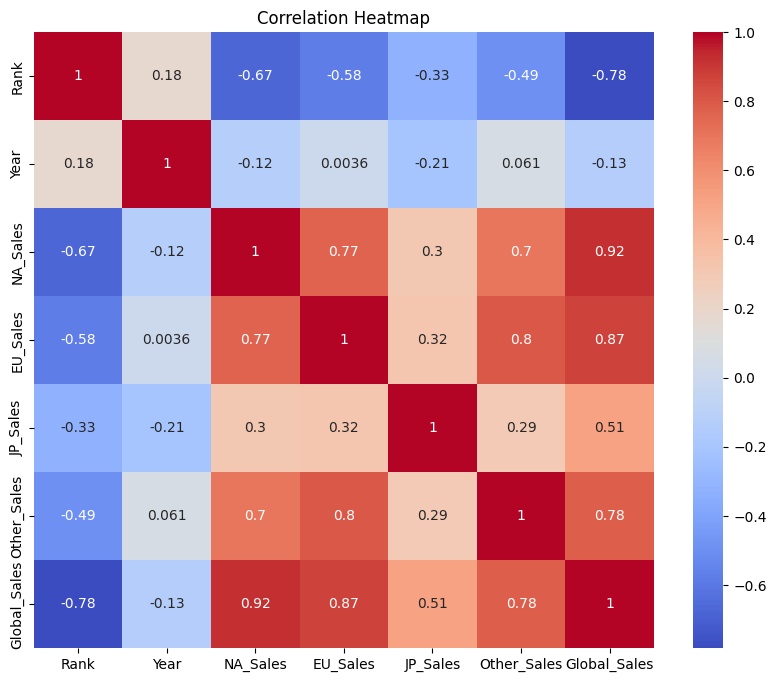

In [ ]:
#Bivariate and Multivariate Analysis
#Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

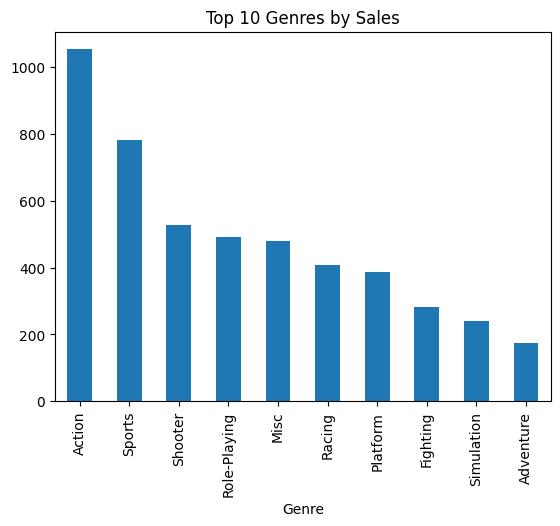

In [ ]:
#Top 10 Genres by Sales
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
genre_sales.head(10).plot(kind='bar')
plt.title('Top 10 Genres by Sales')
plt.show()

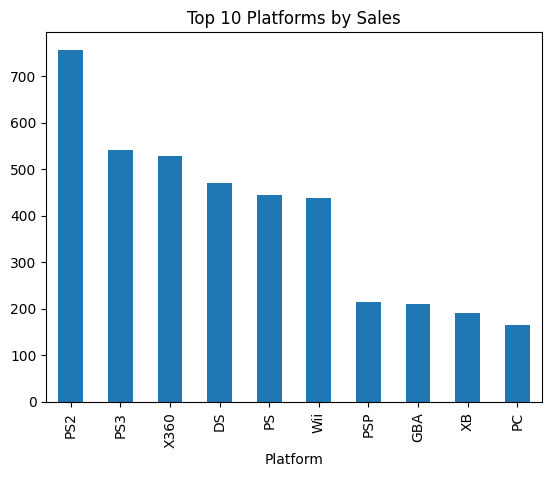

In [ ]:
#Top 10 Platforms by Sales.......
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)
platform_sales.head(10).plot(kind='bar')
plt.title('Top 10 Platforms by Sales')
plt.show()

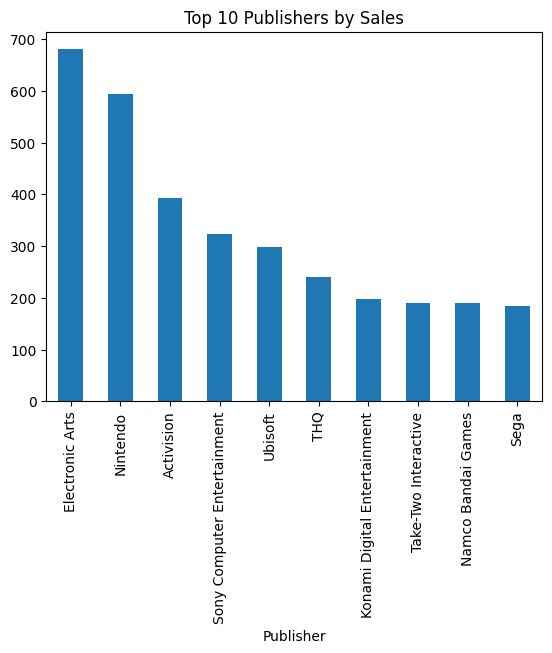

In [ ]:
#Top 10 publishers by sales........
publisher_sales = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False)
publisher_sales.head(10).plot(kind='bar')
plt.title('Top 10 Publishers by Sales')
plt.show()

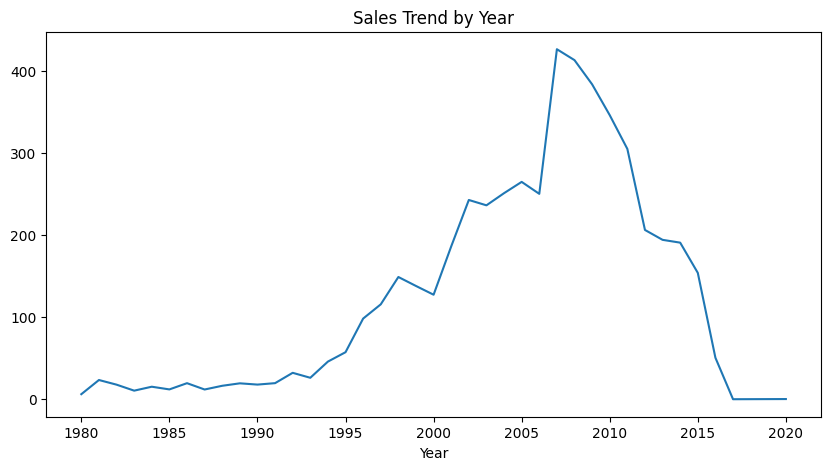

In [ ]:
#Sales trend by year
year_sales = df.groupby('Year')['Global_Sales'].sum()
plt.figure(figsize=(10, 5))
year_sales.plot()
plt.title('Sales Trend by Year')
plt.show()

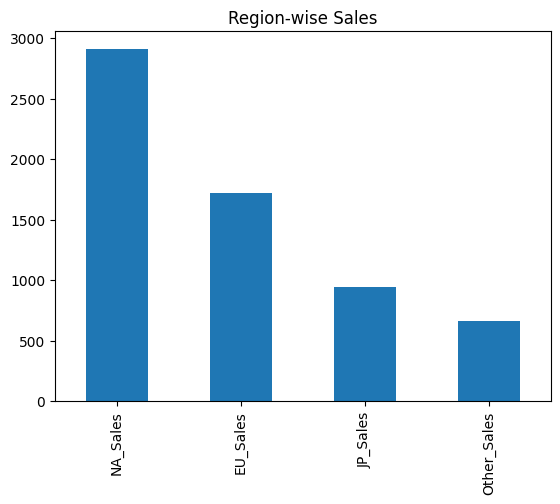

In [ ]:
#Region-wise comparison
region_sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
region_sales.plot(kind='bar')
plt.title('Region-wise Sales')
plt.show()

In [ ]:
#Creating new feature
df['Game_Age']=  2025 - df['Year']

In [ ]:
#One Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Genre'], drop_first=True)

In [ ]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Platform_Label'] = le.fit_transform(df['Platform'])

In [ ]:
df.drop('Platform', axis=1, inplace=True)

In [ ]:
df.head(10)

,Rank,Name,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Game_Age,Platform_Label
0,1,Wii Sports,2006.0,Sports,Nintendo,3.749269,3.401864,1.562346,2.247072,4.427717,19.0,26
1,2,Super Mario Bros.,1985.0,Platform,Nintendo,3.403860,1.521699,2.055405,0.570980,3.719409,40.0,11
2,3,Mario Kart Wii,2008.0,Racing,Nintendo,2.824351,2.630449,1.566530,1.460938,3.606041,17.0,26
3,4,Wii Sports Resort,2009.0,Sports,Nintendo,2.818398,2.485740,1.453953,1.376244,3.526361,16.0,26
4,5,Pokemon Red/Pokemon Blue,1996.0,Role-Playing,Nintendo,2.507157,2.291524,2.417698,0.693147,3.477232,29.0,5
5,6,Tetris,1989.0,Puzzle,Nintendo,3.186353,1.181727,1.652497,0.457425,3.442339,36.0,5
6,7,New Super Mario Bros.,2006.0,Platform,Nintendo,2.516082,2.325325,2.014903,1.360977,3.434310,19.0,4
7,8,Wii Play,2006.0,Misc,Nintendo,2.710048,2.322388,1.368639,1.348073,3.401864,19.0,26
8,9,New Super Mario Bros. Wii,2009.0,Platform,Nintendo,2.746630,2.086914,1.740466,1.181727,3.388450,16.0,26
9,10,Duck Hunt,1984.0,Shooter,Nintendo,3.329701,0.488580,0.246860,0.385262,3.377929,41.0,11
